# 03 — Robust summaries and association checks
## Context & methods
This is descriptive analysis of the observed PhonePe geography set, not a random sample of Indian consumers or merchants. We use medians, IQR fences and Spearman correlations because the cross-sectional measures have long tails. Outliers are flags for investigation, not automatic deletion. No causal effect, population confidence interval or significance claim is estimated.

## tl;dr

- Uses robust summaries because district measures are skewed and contain genuine large-market extremes.
- Quantifies outlier influence without deleting observations and reports the complete Spearman correlation structure.
- Tests whether pooled density/growth relationships differ within states and explains reciprocal and shared-denominator ratios.
- Demonstrates: robust statistics, association analysis, confounding awareness, selection-bias checks, and cautious interpretation.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from phonepe_analytics.analysis import ANALYSIS_DIR, MEASURES, descriptive_statistics
from phonepe_analytics.config import EDA_CHART_DIR

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})
PURPLE, TEAL, GRAY = "#5F259F", "#087F8C", "#697386"
EDA_CHART_DIR.mkdir(parents=True, exist_ok=True)


def save_chart(fig, name):
    fig.tight_layout()
    fig.savefig(EDA_CHART_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


district = pd.read_csv(ANALYSIS_DIR / "district_metrics.csv")
state = pd.read_csv(ANALYSIS_DIR / "state_metrics.csv")
national = pd.read_csv(ANALYSIS_DIR / "national_metrics.csv").sort_values("period_id")
latest_period = district.period_id.max()
latest = district.loc[district.period_id.eq(latest_period)].copy()
state_latest = state.loc[state.period_id.eq(latest_period)].copy()
eligible = pd.read_csv(ANALYSIS_DIR / "district_opportunities.csv")
period = latest.period_label.iloc[0]

LABELS = {
    "transaction_count": "Quarterly transactions",
    "transaction_amount": "Transaction value (INR)",
    "registered_users": "Registered users",
    "registered_merchants": "Registered merchants",
    "average_transaction_value": "Average transaction value (INR)",
    "users_per_merchant": "Users per merchant",
    "merchants_per_100k_users": "Merchants per 100K users",
    "transactions_per_registered_user": "Transactions per registered user",
    "tpv_per_registered_user": "Value per registered user (INR)",
    "transactions_per_merchant": "Transactions per merchant",
    "transaction_qoq": "Transaction QoQ growth",
    "tpv_qoq": "Value QoQ growth",
    "user_qoq": "User QoQ growth",
    "merchant_qoq": "Merchant QoQ growth",
    "transaction_yoy": "Transaction YoY growth",
}

## Data — complete latest-quarter districts and the eligible scoring subset

,count,missing,50%,mean,std,skewness,iqr,iqr_outliers
metric,,,,,,,,
transaction_count,783.0,0,2.444644e+07,4.937968e+07,1.111778e+08,11.012642,4.947215e+07,49
transaction_amount,783.0,0,2.949028e+10,5.810530e+10,1.197750e+11,10.248696,5.830062e+10,51
registered_users,783.0,0,6.113150e+05,9.088803e+05,1.341768e+06,6.913970,8.436420e+05,48
registered_merchants,783.0,0,3.885400e+04,6.475766e+04,1.084056e+05,6.679101,6.124000e+04,56
average_transaction_value,783.0,0,1.192238e+03,1.236841e+03,2.298757e+02,1.408696,2.459068e+02,29
users_per_merchant,783.0,0,1.628774e+01,3.235200e+01,9.688204e+01,13.693059,8.928820e+00,92
merchants_per_100k_users,783.0,0,6.139588e+03,5.976175e+03,2.397867e+03,-0.262922,3.078337e+03,3
transactions_per_registered_user,783.0,0,4.071834e+01,4.392831e+01,2.289651e+01,0.914775,2.643840e+01,38
tpv_per_registered_user,783.0,0,4.649192e+04,5.419152e+04,3.226021e+04,1.515259,3.156914e+04,64


,All districts,Eligible districts,Eligible/all median
metric,,,
transaction_count,2.444644e+07,3.027936e+07,1.239
transaction_amount,2.949028e+10,3.657015e+10,1.240
registered_users,6.113150e+05,7.047250e+05,1.153
registered_merchants,3.885400e+04,4.611000e+04,1.187
average_transaction_value,1.192238e+03,1.185890e+03,0.995
users_per_merchant,1.628800e+01,1.552400e+01,0.953
merchants_per_100k_users,6.139588e+03,6.441486e+03,1.049
transactions_per_registered_user,4.071800e+01,4.337600e+01,1.065
tpv_per_registered_user,4.649192e+04,5.065153e+04,1.089


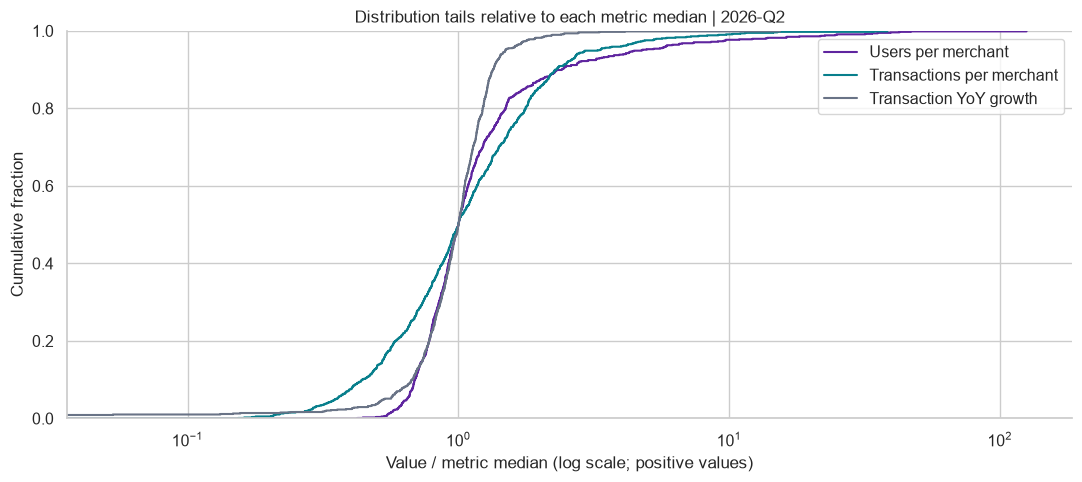

**Insight:** the eligible/all median comparison makes selection effects visible. Size thresholds deliberately favor larger districts; the scoring subset should not describe a typical district across the entire country. The ECDF shows relative positive tails; zero/negative growth is retained in the preceding statistics and EDA histograms, even though it cannot appear on a logarithmic axis.

In [2]:
stats = descriptive_statistics(latest, MEASURES)
display(stats[["count", "missing", "50%", "mean", "std", "skewness", "iqr", "iqr_outliers"]])
fig, ax = plt.subplots(figsize=(11, 5))
comparison = pd.DataFrame(
    {
        "All districts": stats["50%"],
        "Eligible districts": descriptive_statistics(eligible, MEASURES)["50%"],
    }
)
comparison["Eligible/all median"] = comparison["Eligible districts"] / comparison["All districts"]
display(comparison.round(3))
selected = ["users_per_merchant", "transactions_per_merchant", "transaction_yoy"]
for column, color in zip(selected, [PURPLE, TEAL, GRAY], strict=True):
    normalized = latest[column] / latest[column].median()
    sns.ecdfplot(normalized, ax=ax, label=LABELS[column], color=color)
ax.set(
    xscale="log",
    title=f"Distribution tails relative to each metric median | {period}",
    xlabel="Value / metric median (log scale; positive values)",
    ylabel="Cumulative fraction",
)
ax.legend()
save_chart(fig, "03_robust_distributions")
display(
    Markdown(
        "**Insight:** the eligible/all median comparison makes selection effects visible. "
        "Size thresholds deliberately favor larger districts; the scoring subset should "
        "not describe a typical district across the entire country. The ECDF shows "
        "relative positive tails; zero/negative growth is retained in the preceding "
        "statistics and EDA histograms, even though it cannot appear on a logarithmic axis."
    )
)

## Results — outlier influence without deleting observations

In [3]:
outlier_rows = []
for column in MEASURES:
    values = latest[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    inside = values.between(q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1))
    outlier_rows.append(
        {
            "Metric": LABELS[column],
            "Full mean": values.mean(),
            "Mean inside fences": values[inside].mean(),
            "Median": values.median(),
            "Flagged": int((~inside).sum()),
        }
    )
display(pd.DataFrame(outlier_rows).round(3))
display(
    latest.nlargest(8, "users_per_merchant")[
        [
            "state",
            "district",
            "users_per_merchant",
            "registered_users",
            "registered_merchants",
            "transaction_yoy",
        ]
    ].round(3)
)
display(
    Markdown(
        "**Insight:** the full-versus-inside-fence means quantify how extreme districts "
        "change the average. Flags can represent genuine large markets or unusual "
        "registration density, not data errors. Keep them in the source and use "
        "percentiles to limit score domination; review the displayed denominators "
        "before taking high ratios as business opportunity."
    )
)

,Metric,Full mean,Mean inside fences,Median,Flagged
0,Quarterly transactions,4.937968e+07,3.177935e+07,2.444644e+07,49
1,Transaction value (INR),5.810530e+10,3.835890e+10,2.949028e+10,51
2,Registered users,9.088803e+05,6.695517e+05,6.113150e+05,48
3,Registered merchants,6.475766e+04,4.365497e+04,3.885400e+04,56
4,Average transaction value (INR),1.236841e+03,1.210457e+03,1.192238e+03,29
5,Users per merchant,3.235200e+01,1.655700e+01,1.628800e+01,92
6,Merchants per 100K users,5.976175e+03,5.947022e+03,6.139588e+03,3
7,Transactions per registered user,4.392800e+01,4.091100e+01,4.071800e+01,38
8,Value per registered user (INR),5.419152e+04,4.661259e+04,4.649192e+04,64
9,Transactions per merchant,1.019145e+03,7.811370e+02,7.101560e+02,42


,state,district,users_per_merchant,registered_users,registered_merchants,transaction_yoy
16387,nagaland,noklak,2044.000,4088,2.0,0.350
1019,arunachal pradesh,anjaw,762.875,12206,16.0,0.325
16489,nagaland,shamator,693.800,3469,5.0,0.437
15095,manipur,pherzawl,642.667,1928,3.0,0.841
15571,meghalaya,south west khasi hills,576.684,10957,19.0,0.143
15401,meghalaya,eastern west khasi hills,549.429,7692,14.0,0.417
15061,manipur,noney,519.000,11418,22.0,0.197
1699,arunachal pradesh,shi yomi,407.267,6109,15.0,1.042


**Insight:** the full-versus-inside-fence means quantify how extreme districts change the average. Flags can represent genuine large markets or unusual registration density, not data errors. Keep them in the source and use percentiles to limit score domination; review the displayed denominators before taking high ratios as business opportunity.

### Correlation structure — every analytical measure

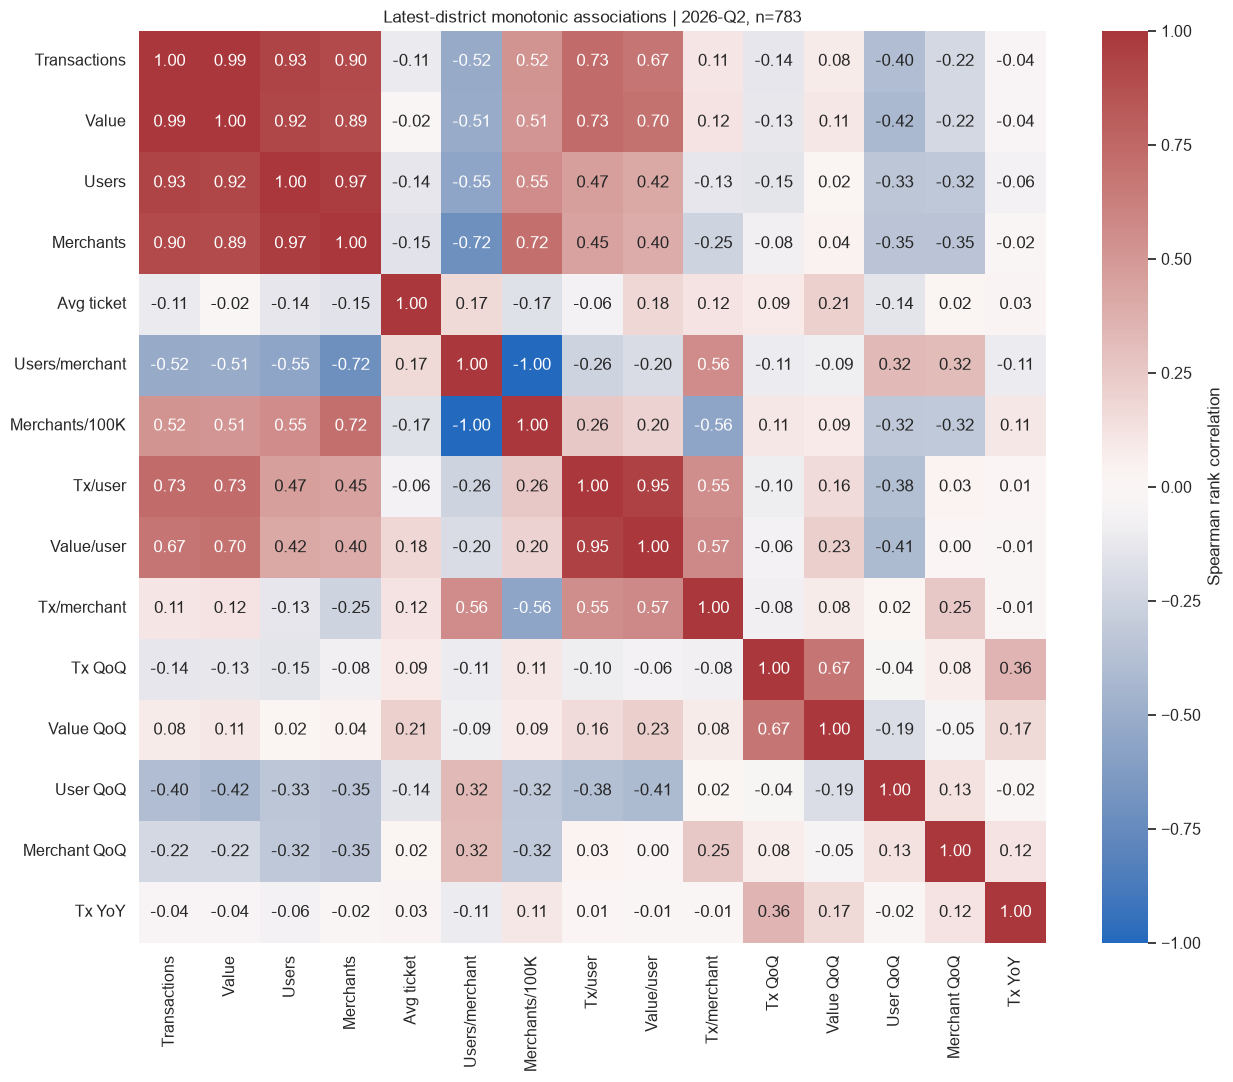

**Insight:** users and transaction volume have rho=0.933; merchant-normalized user and transaction ratios have rho=0.561. Users per merchant and merchants per 100K users are reciprocals and therefore redundant signals. The two per-merchant demand ratios share a denominator, so their association partly reflects arithmetic. The score includes only one density direction and tests removing transaction intensity entirely. Do not interpret these correlations as merchant-acquisition effects.

In [4]:
corr = latest[MEASURES].corr(method="spearman")
short = [
    "Transactions",
    "Value",
    "Users",
    "Merchants",
    "Avg ticket",
    "Users/merchant",
    "Merchants/100K",
    "Tx/user",
    "Value/user",
    "Tx/merchant",
    "Tx QoQ",
    "Value QoQ",
    "User QoQ",
    "Merchant QoQ",
    "Tx YoY",
]
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    annot=True,
    fmt=".2f",
    xticklabels=short,
    yticklabels=short,
    ax=ax,
    cbar_kws={"label": "Spearman rank correlation"},
)
ax.set(title=f"Latest-district monotonic associations | {period}, n={len(latest)}")
save_chart(fig, "03_correlation_heatmap")
display(
    Markdown(
        f"**Insight:** users and transaction volume have "
        f"rho={corr.loc['registered_users', 'transaction_count']:.3f}; "
        f"merchant-normalized user and transaction ratios have "
        f"rho={corr.loc['users_per_merchant', 'transactions_per_merchant']:.3f}. "
        "Users per merchant and merchants per 100K users are reciprocals and therefore redundant "
        "signals. The two per-merchant demand ratios share a denominator, so their association "
        "partly reflects arithmetic. The score includes only one density direction and tests "
        "removing transaction intensity entirely. Do not interpret these correlations "
        "as merchant-acquisition effects."
    )
)

### Within-state associations — geography as a third variable

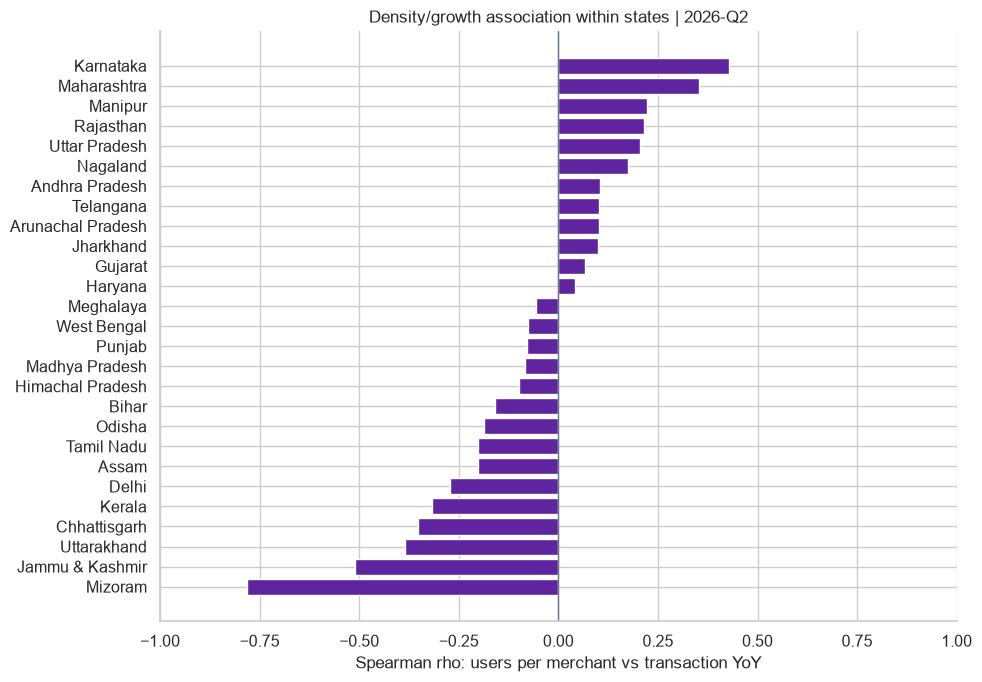

,State,Districts,Density vs growth,Users vs transactions
17,Mizoram,11,-0.782,0.927
9,Jammu & Kashmir,22,-0.510,0.967
25,Uttarakhand,13,-0.385,0.934
4,Chhattisgarh,33,-0.352,0.982
12,Kerala,14,-0.319,0.978
5,Delhi,11,-0.273,0.927
2,Assam,35,-0.202,0.929
22,Tamil Nadu,38,-0.202,0.953
19,Odisha,30,-0.186,0.955
3,Bihar,38,-0.159,0.982


**Insight:** among states with at least ten districts, density/growth rho ranges from -0.782 to 0.429. A pooled nationwide association can hide different within-state patterns. The ten-district cutoff is a descriptive display rule, not a significance threshold. Pair national ranks with local commercial validation; do not infer a common response to adding merchants.

In [5]:
within = []
for state_name, rows in latest.groupby("state"):
    if len(rows) >= 10:
        within.append(
            {
                "State": state_name.title(),
                "Districts": len(rows),
                "Density vs growth": rows.users_per_merchant.corr(
                    rows.transaction_yoy, method="spearman"
                ),
                "Users vs transactions": rows.registered_users.corr(
                    rows.transaction_count, method="spearman"
                ),
            }
        )
within = pd.DataFrame(within).sort_values("Density vs growth")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(within.State, within["Density vs growth"], color=PURPLE)
ax.axvline(0, color=GRAY, linewidth=1)
ax.set(
    xlim=(-1, 1),
    title=f"Density/growth association within states | {period}",
    xlabel="Spearman rho: users per merchant vs transaction YoY",
)
save_chart(fig, "03_within_state_associations")
display(within.round(3))
display(
    Markdown(
        f"**Insight:** among states with at least ten districts, density/growth rho ranges from "
        f"{within['Density vs growth'].min():.3f} to {within['Density vs growth'].max():.3f}. "
        "A pooled nationwide association can hide different within-state patterns. "
        "The ten-district "
        "cutoff is a descriptive display rule, not a significance threshold. Pair national ranks "
        "with local commercial validation; do not infer a common response to adding merchants."
    )
)

## Takeaways
Use medians and percentiles with size context. Preserve outliers unless source evidence establishes an error. Separate scale associations, reciprocal ratios and shared-denominator associations from independent business evidence. The score is a transparent prioritization rule whose stability must be checked, not a fitted model or statistically proven optimum.